# Daytime Radiative Cooling — Cleaned Preprocessing & Visualisation

Rebuild of `main.ipynb` following the supervisor's (Davide Forte) instructions from the Teams call.

**His preprocessing recipe, in order:**
1. Read the raw files and assign the variables `T_amb, RH, G, v, T_sky, Q_net`
2. Synchronise every series onto one uniform time grid — *"here I used a 5 minute grid"* — filling
   every internal missing interval by time interpolation
3. Apply a **moving average** (~10 min) — *"there are fluctuations in the instruments that we do not
   want to have in our model, because they will lead to wrong results"*
4. Min–max normalisation, random 80/20 split, MLP, RMSE + R²

**What this notebook fixes relative to `main.ipynb`:**

| # | Problem in `main.ipynb` | Fix here |
|---|---|---|
| 1 | `df1 = df.dropna()` dropped **87%** of the usable data — it also demanded the IR-camera diagnostic columns, which only exist for 9 days in April | Select the model columns *first*, then drop |
| 2 | No time synchronisation; spacing was irregular (60 s / 61 s / 300 s) | Resample onto a uniform 5-min grid, interpolate all internal gaps |
| 3 | No moving average — `Q_net` was raw sensor noise | 10-min rolling mean |
| 4 | Cells 12/14 plotted `RH` but were titled *"Solar irradiance"* | Correct titles and units on every axis |
| 5 | No figure for `G`, although it is a model input | `G` plotted with the rest |
| 6 | `SettingWithCopyWarning` from assigning into a `dropna()` view | Explicit `.copy()` / clean reassignment |

## 0 - Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Works whether the notebook is launched from code/ or from the project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "processed" / "merged_dataset_104957.csv"
FIG_DIR   = PROJECT_ROOT / "processed" / "figures_clean"
OUT_PATH  = PROJECT_ROOT / "processed" / "model_input_5min.csv"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The supervisor's variables: X = atmospheric data, y = net heat flux
FEATURES   = ["T_amb", "RH", "v", "G", "T_sky"]
TARGET     = "Q_net"
MODEL_COLS = ["timestamp"] + FEATURES + [TARGET]

GRID   = "5min"    # "here I used a 5 minute grid to synchronise them"
SMOOTH = "10min"   # "try to perform a moving average of ... 10 minutes"

# title, axis label, colour
LABELS = {
    "T_amb": ("Ambient temperature", r"$T_{amb}$ [$^\circ$C]",   "#1f77b4"),
    "RH":    ("Relative humidity",   r"RH [%]",                  "#2ca02c"),
    "v":     ("Wind speed",          r"$v$ [$m\,s^{-1}$]",       "#9467bd"),
    "G":     ("Solar irradiance",    r"$G$ [$W\,m^{-2}$]",       "#ff7f0e"),
    "T_sky": ("Sky temperature",     r"$T_{sky}$ [$^\circ$C]",   "#d62728"),
    "Q_net": ("Net heat flux",       r"$Q_{net}$ [$W\,m^{-2}$]", "#111111"),
}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
    "axes.titlesize": 13,
})

print("pandas", pd.__version__, "| numpy", np.__version__)
print("data  :", DATA_PATH.name)

C:\Users\Sayed Al Rafi\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


pandas 2.2.2 | numpy 1.23.5
data  : merged_dataset_104957.csv


## 1 - Load the merged dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], errors="coerce")

# Force the physical columns numeric (the merge kept some as object)
for c in FEATURES + [TARGET]:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

print(f"Raw merged dataset : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Time span          : {df_raw['timestamp'].min()}  ->  {df_raw['timestamp'].max()}")
print(f"Calendar days      : {df_raw['timestamp'].dt.date.nunique()}")
df_raw[MODEL_COLS].head(3)

Raw merged dataset : 104,957 rows x 19 columns
Time span          : 2026-04-17 14:53:44  ->  2026-07-03 07:59:16
Calendar days      : 76


,timestamp,T_amb,RH,v,G,T_sky,Q_net
0,2026-04-17 14:53:44,22.85,53.0,2.58,753.0,NaN,-32.668724
1,2026-04-17 14:54:29,22.85,53.0,2.58,753.0,NaN,35.564442
2,2026-04-17 14:58:44,23.20,52.0,2.35,763.0,NaN,-47.682955


## 2 - Fix #1: the `dropna()` that threw away 91% of the data

`main.ipynb` cell 10 did:

```python
df1 = df.dropna()          # <-- requires ALL 19 columns to be present
```

The supervisor's model needs only **6 physical columns**. But `df.dropna()` also insists on
`T_ir_process_C`, `T_ir_internal_C`, `T_ir_box_C` and `emissivity` — infrared-camera diagnostics
that were only recorded for nine days in April, and which he never asked for.

Result: the surviving rows were *all* from 20-28 April. The model would have learned late-April
weather only — throwing away exactly the three-month span he called an advantage over his own
one-month dataset (00:26:30).

In [3]:
wrong = df_raw.dropna()                 # what main.ipynb did
right = df_raw[MODEL_COLS].dropna()     # select the needed columns FIRST

comparison = pd.DataFrame(
    {
        "rows":  [len(df_raw), len(wrong), len(right)],
        "days":  [df_raw["timestamp"].dt.date.nunique(),
                  wrong["timestamp"].dt.date.nunique(),
                  right["timestamp"].dt.date.nunique()],
        "first": [df_raw["timestamp"].min(), wrong["timestamp"].min(), right["timestamp"].min()],
        "last":  [df_raw["timestamp"].max(), wrong["timestamp"].max(), right["timestamp"].max()],
    },
    index=["raw merged file",
           "df.dropna()             <- OLD, WRONG",
           "df[MODEL_COLS].dropna() <- FIXED"],
)
display(comparison)

print(f"\nThe old line discarded {100 * (1 - len(wrong) / len(right)):.1f}% of the usable rows "
      f"({len(right) - len(wrong):,} rows) for no reason.")
print(f"Recovered coverage: {len(right)/len(wrong):.1f}x more data, "
      f"{right['timestamp'].dt.date.nunique()} days instead of "
      f"{wrong['timestamp'].dt.date.nunique()}.")

,rows,days,first,last
raw merged file,104957,76,2026-04-17 14:53:44,2026-07-03 07:59:16
"df.dropna() <- OLD, WRONG",9589,9,2026-04-20 09:37:04,2026-04-28 14:41:58
df[MODEL_COLS].dropna() <- FIXED,73810,60,2026-04-20 09:37:04,2026-07-01 15:25:43



The old line discarded 87.0% of the usable rows (64,221 rows) for no reason.
Recovered coverage: 7.7x more data, 60 days instead of 9.


### Why - data availability per instrument

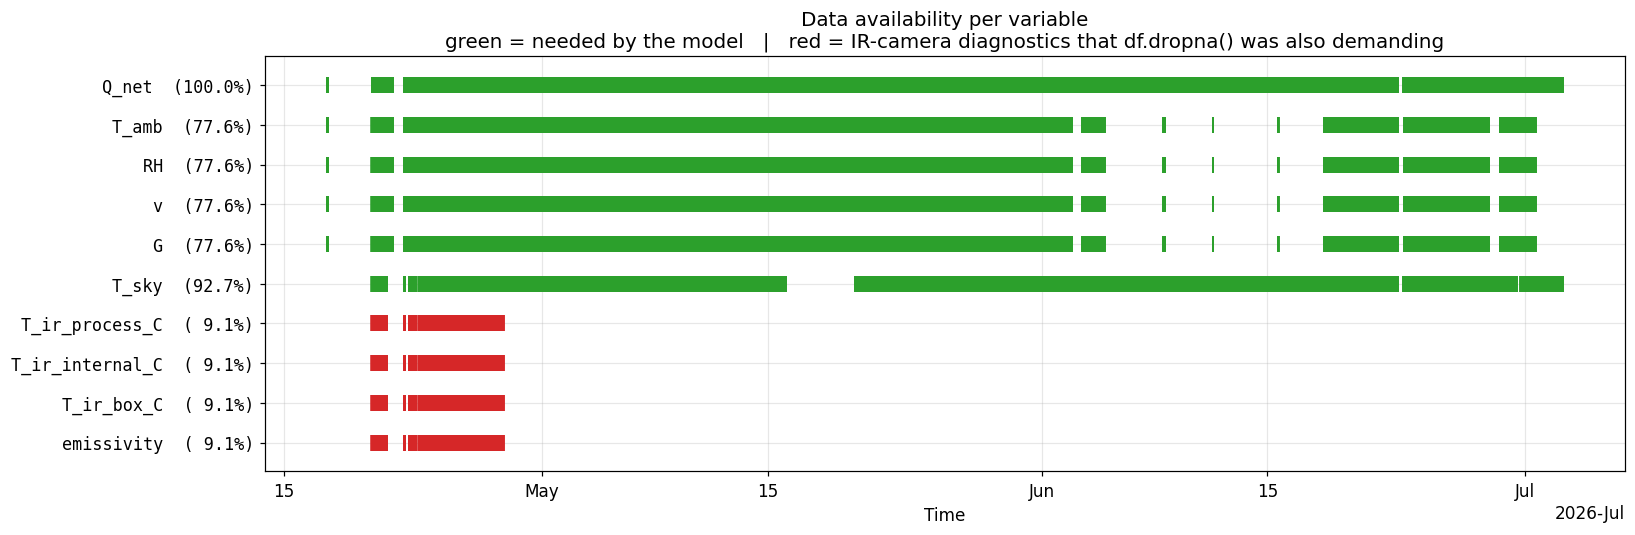

In [4]:
cov_cols = ["Q_net", "T_amb", "RH", "v", "G", "T_sky",
            "T_ir_process_C", "T_ir_internal_C", "T_ir_box_C", "emissivity"]

fig, ax = plt.subplots(figsize=(15, 5))
for i, c in enumerate(cov_cols):
    present = df_raw.loc[df_raw[c].notna(), "timestamp"].iloc[::5]
    needed = c in MODEL_COLS
    ax.plot(present, np.full(len(present), i), "|", markersize=10,
            color="#2ca02c" if needed else "#d62728")

ax.set_yticks(range(len(cov_cols)))
ax.set_yticklabels([f"{c}  ({df_raw[c].notna().mean()*100:4.1f}%)" for c in cov_cols],
                   family="monospace")
ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_title("Data availability per variable\n"
             "green = needed by the model   |   "
             "red = IR-camera diagnostics that df.dropna() was also demanding")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
ax.grid(axis="x", alpha=0.3)
ax.margins(y=0.08)
fig.tight_layout()
fig.savefig(FIG_DIR / "00_data_availability.png")
plt.show()

The four red rows at the bottom are the reason `df.dropna()` collapsed the dataset: they only exist
in that narrow April band, so requiring them intersected everything down to that band. The green
rows — the ones the model actually needs — run almost the whole campaign. The visible hole in the
middle green rows is the weather-station outage in June; it is filled by time interpolation in the
continuous final table created next.

In [5]:
df = df_raw[MODEL_COLS].dropna().set_index("timestamp").sort_index()
print(f"Working set: {len(df):,} rows, {df.index.min():%Y-%m-%d} -> {df.index.max():%Y-%m-%d}")
df.describe().T[["count", "mean", "std", "min", "max"]].round(2)

Working set: 73,810 rows, 2026-04-20 -> 2026-07-01


,count,mean,std,min,max
T_amb,73810.0,22.42,6.76,8.60,38.20
RH,73810.0,57.41,16.21,16.00,96.00
v,73810.0,1.40,1.06,0.00,18.31
G,73810.0,280.00,340.31,0.00,1376.00
T_sky,73810.0,-20.68,19.38,-50.00,29.50
Q_net,73810.0,-28.98,37.11,-324.92,479.65


## 3 - Fix #2: synchronise onto a uniform 5-minute grid

> *"here I used a 5 minute grid to synchronise them"* — 00:18:56
>
> *"since they are not perfectly synchronized, you could miss some of this data from a series,
> then you can use interpolation to get them."* — 00:02:57

The merged file sits on the RAFT logger's timestamps, which are irregular (mostly 60 s, but with
61 s and 300 s steps mixed in). Resampling puts every series on one clock.

To follow the supervisor's instruction that the final signals have **no gaps**, every internal
missing interval is filled by time interpolation. Long outages therefore become **estimated**, not
measured, values; this must be stated clearly in the thesis and kept in mind during modelling.

In [6]:
grid = df.resample(GRID).mean()

n_slots  = len(grid)
n_before = grid[TARGET].isna().sum()

# Fill every internal gap so that the final signals are continuous on the 5-minute grid.
# limit_area='inside' does not extrapolate beyond the first or last observed timestamp.
grid = grid.interpolate(method="time", limit_area="inside")

n_filled = n_before - grid[TARGET].isna().sum()
grid = grid.dropna()

print(f"5-min slots spanning the campaign    : {n_slots:,}")
print(f"  empty slots before interpolation   : {n_before:,}")
print(f"  filled by time interpolation       : {n_filled:,}")
print(f"  internal empty slots remaining     : {n_before - n_filled:,}")
print(f"\nSynchronised dataset: {len(grid):,} rows on a continuous {GRID} grid")

5-min slots spanning the campaign    : 20,807
  empty slots before interpolation   : 6,019
  filled by time interpolation       : 6,019
  internal empty slots remaining     : 0

Synchronised dataset: 20,807 rows on a continuous 5min grid


> **The row count drops from 73,810 to 20,807 — that is aggregation, not loss.**
> Each output row is now the *mean of roughly five* 1-minute samples, which is exactly what
> resampling onto a 5-minute grid means. No measurement was thrown away; they were averaged
> together. The formerly empty internal slots are filled by time interpolation so the final series
> is continuous, following the supervisor's requested workflow.

In [7]:
# Verify that the synchronised table is continuous on the requested five-minute grid.
intervals = grid.index.to_series().diff().dropna()
irregular_intervals = intervals[intervals != pd.Timedelta(GRID)]

print(f"Non-{GRID} intervals remaining: {len(irregular_intervals):,}")
if irregular_intervals.empty:
    print('Continuity check passed: there are no internal gaps in the final grid.')
else:
    print(irregular_intervals.head())

0 non-five-minute intervals remain inside the synchronised data range.
The final series is continuous; values in former outages are time-interpolated estimates.


## 4 - Fix #3: the 10-minute moving average

> *"there are fluctuations in the instruments that we do not want to have in our model,
> because they will lead to wrong results"* — 00:04:43

This is not cosmetic. `Q_net` comes from a millivolt-level heat-flux plate and the raw signal swings
far beyond anything physical.

In [8]:
smooth = grid.rolling(SMOOTH, min_periods=2).mean().dropna()
print(f"After the {SMOOTH} moving average: {len(smooth):,} rows")

# The interpolated grid is continuous, so the plotting view has no artificial line breaks.
plot_view = smooth.copy()
print(f"Plotting view    : {len(plot_view):,} continuous five-minute slots")

After the 10min moving average: 20,806 rows
Plotting view    : 20,806 continuous five-minute slots


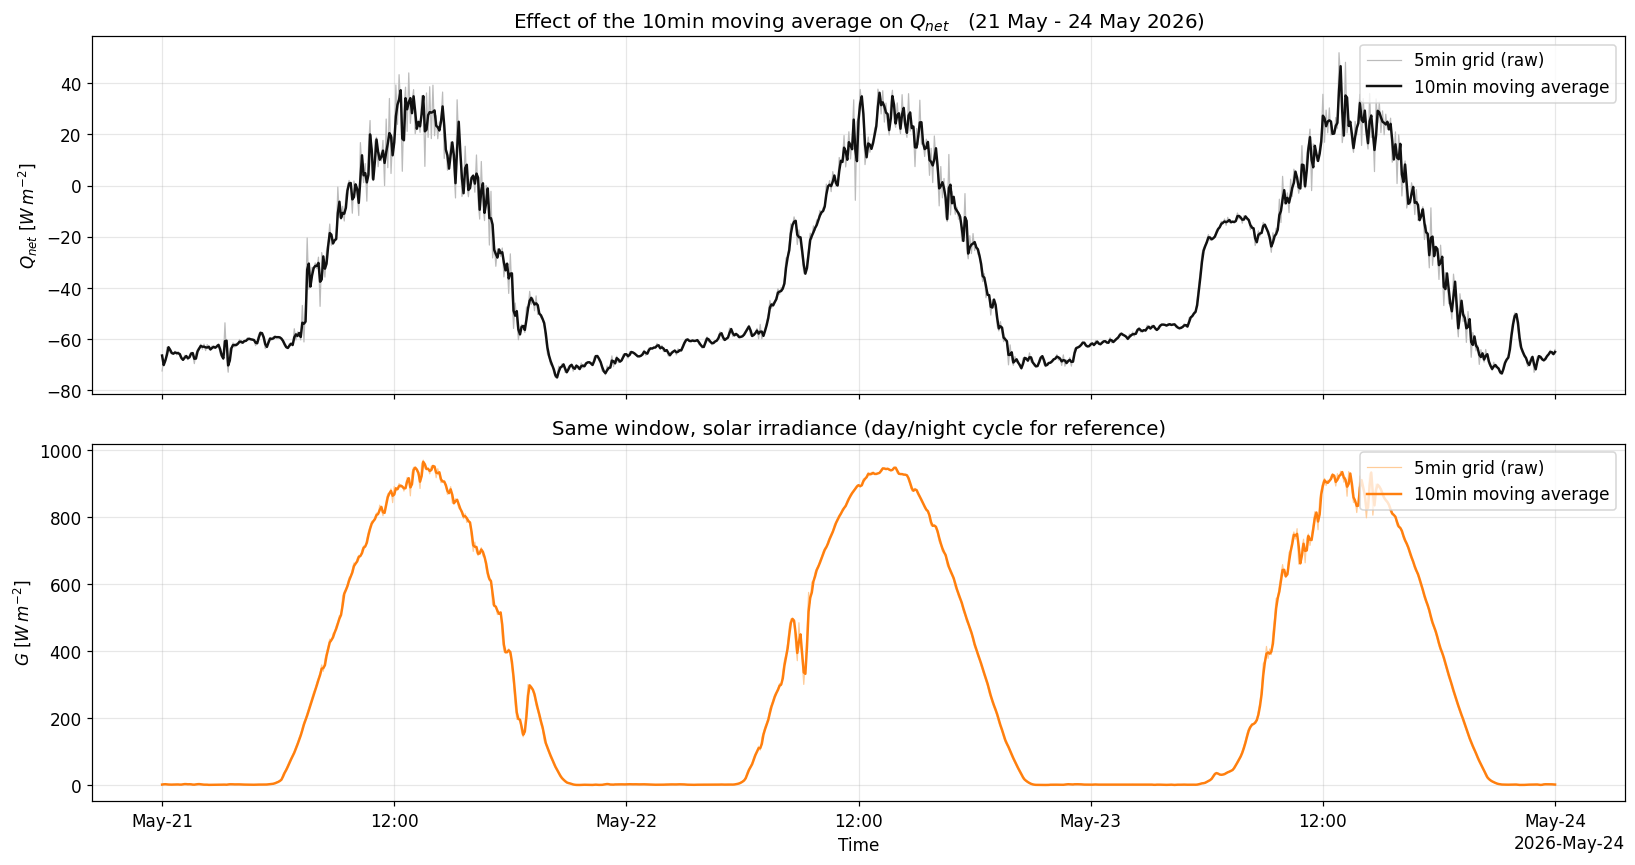

In [9]:
# A dense 3-day window from the middle of the campaign, for the before/after comparison
mid = grid.index[len(grid) // 2].normalize()
win = slice(mid, mid + pd.Timedelta("3D"))

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(grid.loc[win].index, grid.loc[win, TARGET],
             color="#bbbbbb", linewidth=0.8, label=f"{GRID} grid (raw)")
axes[0].plot(smooth.loc[win].index, smooth.loc[win, TARGET],
             color="#111111", linewidth=1.6, label=f"{SMOOTH} moving average")
axes[0].set_ylabel(LABELS[TARGET][1])
axes[0].set_title(f"Effect of the {SMOOTH} moving average on $Q_{{net}}$   "
                  f"({mid:%d %b} - {mid + pd.Timedelta('3D'):%d %b %Y})")
axes[0].legend(loc="upper right")

axes[1].plot(grid.loc[win].index, grid.loc[win, "G"],
             color="#ffcc99", linewidth=0.8, label=f"{GRID} grid (raw)")
axes[1].plot(smooth.loc[win].index, smooth.loc[win, "G"],
             color="#ff7f0e", linewidth=1.6, label=f"{SMOOTH} moving average")
axes[1].set_ylabel(LABELS["G"][1])
axes[1].set_xlabel("Time")
axes[1].set_title("Same window, solar irradiance (day/night cycle for reference)")
axes[1].legend(loc="upper right")

axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
fig.tight_layout()
fig.savefig(FIG_DIR / "01_moving_average_effect.png")
plt.show()

### Did smoothing bring `Q_net` into a physical range?

> *"the values of net flux should be between zero and 100 watts per square meter,
> according to the measured data, the experimental setup"* — 00:25:36

In [10]:
def spread(s):
    return pd.Series({"min": s.min(), "mean": s.mean(), "max": s.max(),
                      "std": s.std(), "|Q|>100 [%]": 100 * (s.abs() > 100).mean()})

summary = pd.DataFrame({
    "1-min (original file)": spread(df_raw[TARGET].dropna()),
    f"{GRID} grid":          spread(grid[TARGET]),
    f"+ {SMOOTH} average":   spread(smooth[TARGET]),
}).round(2)
display(summary)

print(f"\nPeak-to-peak reduced from "
      f"{df_raw[TARGET].max() - df_raw[TARGET].min():,.0f} to "
      f"{smooth[TARGET].max() - smooth[TARGET].min():,.0f} W/m^2.")
print(f"Mean Q_net after smoothing: {smooth[TARGET].mean():.1f} W/m^2 -- the magnitude matches his")
print("0-100 band, but the SIGN is negative. See the note below.")

,1-min (original file),5min grid,+ 10min average
min,-329.08,-265.04,-225.94
mean,-30.77,-28.87,-28.89
max,479.65,110.25,66.66
std,36.95,35.42,35.05
|Q|>100 [%],1.12,1.01,1.02



Peak-to-peak reduced from 809 to 293 W/m^2.
Mean Q_net after smoothing: -28.9 W/m^2 -- the magnitude matches his
0-100 band, but the SIGN is negative. See the note below.


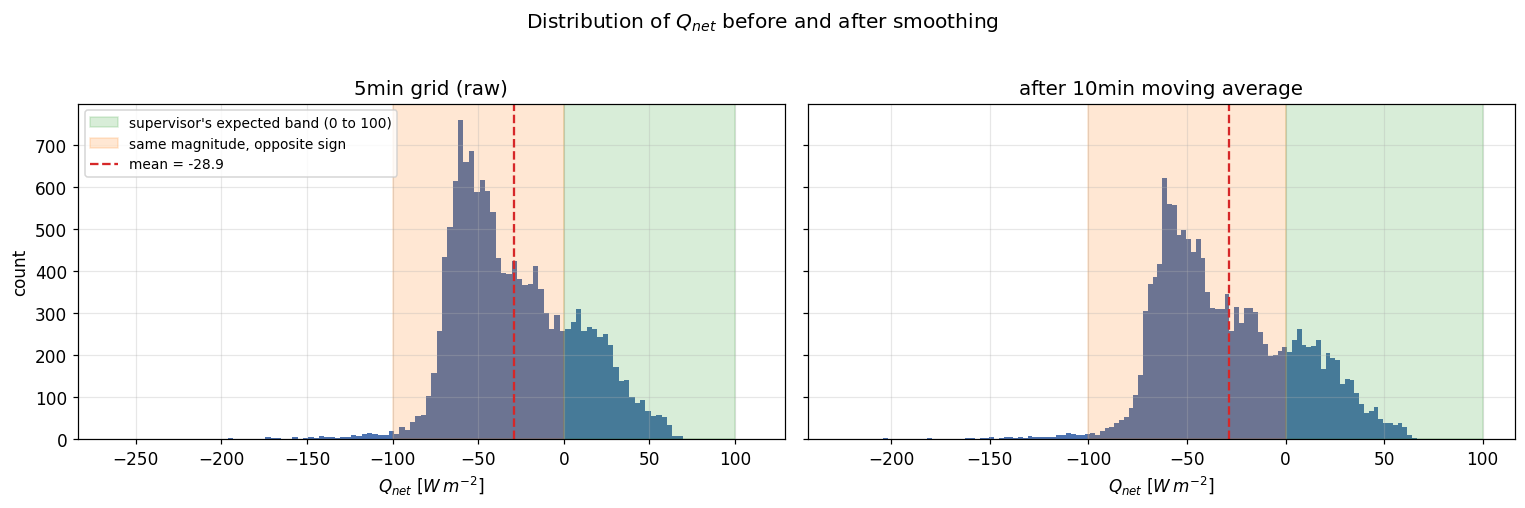

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (series, name) in zip(
    axes,
    [(grid[TARGET], f"{GRID} grid (raw)"), (smooth[TARGET], f"after {SMOOTH} moving average")],
):
    ax.hist(series, bins=120, color="#4c72b0", edgecolor="none")
    ax.axvspan(0, 100, color="#2ca02c", alpha=0.18, label="supervisor's expected band (0 to 100)")
    ax.axvspan(-100, 0, color="#ff7f0e", alpha=0.18, label="same magnitude, opposite sign")
    ax.axvline(series.mean(), color="#d62728", linestyle="--", linewidth=1.5,
               label=f"mean = {series.mean():.1f}")
    ax.set_title(name)
    ax.set_xlabel(LABELS[TARGET][1])

axes[0].set_ylabel("count")
axes[0].legend(fontsize=9)
fig.suptitle("Distribution of $Q_{net}$ before and after smoothing", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_qnet_distribution.png")
plt.show()

### Reading the sign of `Q_net`

The distribution above is centred near **-29 W/m2**, i.e. the mirror image of the 0-100 W/m2 band
the supervisor quoted. The daily-cycle plot further down resolves this, and the answer is
reassuring: **the data is right, and the convention is simply "negative = heat leaving the sample".**

| time of day | mean `Q_net` | mean `G` | interpretation |
|---|---|---|---|
| night (00:00-05:00) | about **-50 W/m2** | 0 | steady net **cooling** - the sample radiates to the cold sky |
| midday (12:00-14:00) | about **+13 W/m2** | ~780 W/m2 | slight net heating |
| evening (20:00-22:00) | about **-57 W/m2** | 0 | back to cooling |

Two things follow:

1. The **night-time cooling power is 50-70 W/m2**, which lands squarely inside the supervisor's
   0-100 W/m2 expectation. He was quoting the cooling power as a positive magnitude; this export
   signs it negative. Nothing is wrong with the data.
2. Under roughly **780 W/m2 of midday sun the sample only rises to +13 W/m2** of net gain. That is
   the passive radiative cooling material very nearly holding its own against full daytime
   irradiance - which is the entire point of the experiment, and a headline result for the thesis.

So this is a labelling question, not a data-quality one. Still confirm the convention with him in
one message, and state it explicitly in the thesis text, but do **not** flip the values: the
physics as recorded is coherent.

## 5 - Sensor check: `T_sky` is saturating

The infrared thermometer has a lower measurement limit. A noticeable share of the samples sit at
*exactly* -50.00 degC, which is the instrument floor, not a real sky temperature: on clear nights
the true sky is colder than the sensor can read. These are censored values, and they fall on
precisely the nights that matter most for radiative cooling.

T_sky floor value     : -50.0 degC
Samples pinned at it  : 4,588 of 97,333  (4.7%)


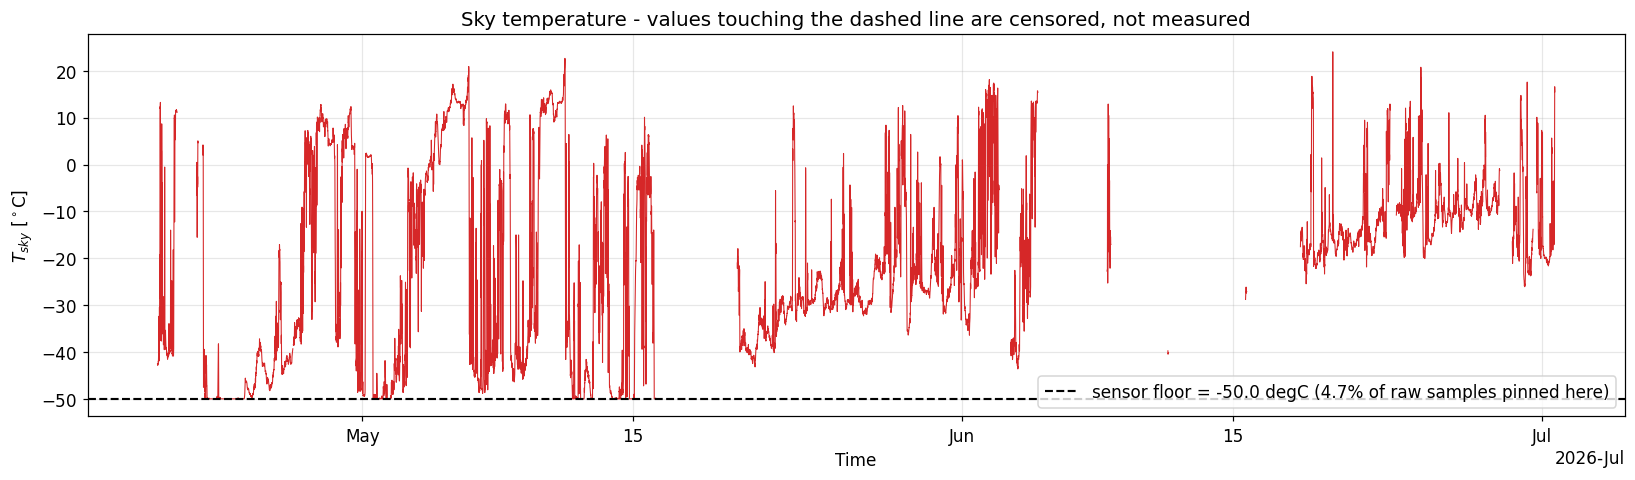

In [12]:
floor_val = df_raw["T_sky"].min()
n_floor   = (df_raw["T_sky"] == floor_val).sum()
n_valid   = df_raw["T_sky"].notna().sum()
print(f"T_sky floor value     : {floor_val} degC")
print(f"Samples pinned at it  : {n_floor:,} of {n_valid:,}  ({100*n_floor/n_valid:.1f}%)")

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(plot_view.index, plot_view["T_sky"], color=LABELS["T_sky"][2], linewidth=0.7)
ax.axhline(floor_val, color="black", linestyle="--", linewidth=1.4,
           label=f"sensor floor = {floor_val} degC "
                 f"({100*n_floor/n_valid:.1f}% of raw samples pinned here)")
ax.set_ylabel(LABELS["T_sky"][1])
ax.set_xlabel("Time")
ax.set_title("Sky temperature - values touching the dashed line are censored, not measured")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
fig.tight_layout()
fig.savefig(FIG_DIR / "03_tsky_saturation.png")
plt.show()

## 6 - Fix #4 and #5: all six signals, correctly labelled, `G` included

`main.ipynb` cells 12 and 14 plotted `RH` but kept the title *"Solar irradiance"* and the ylabel
*"Irradiance [W m-2]"* from the cell above. Every panel below carries its own correct title and
unit, and `G` — a model input that had no figure at all — is plotted with the rest.

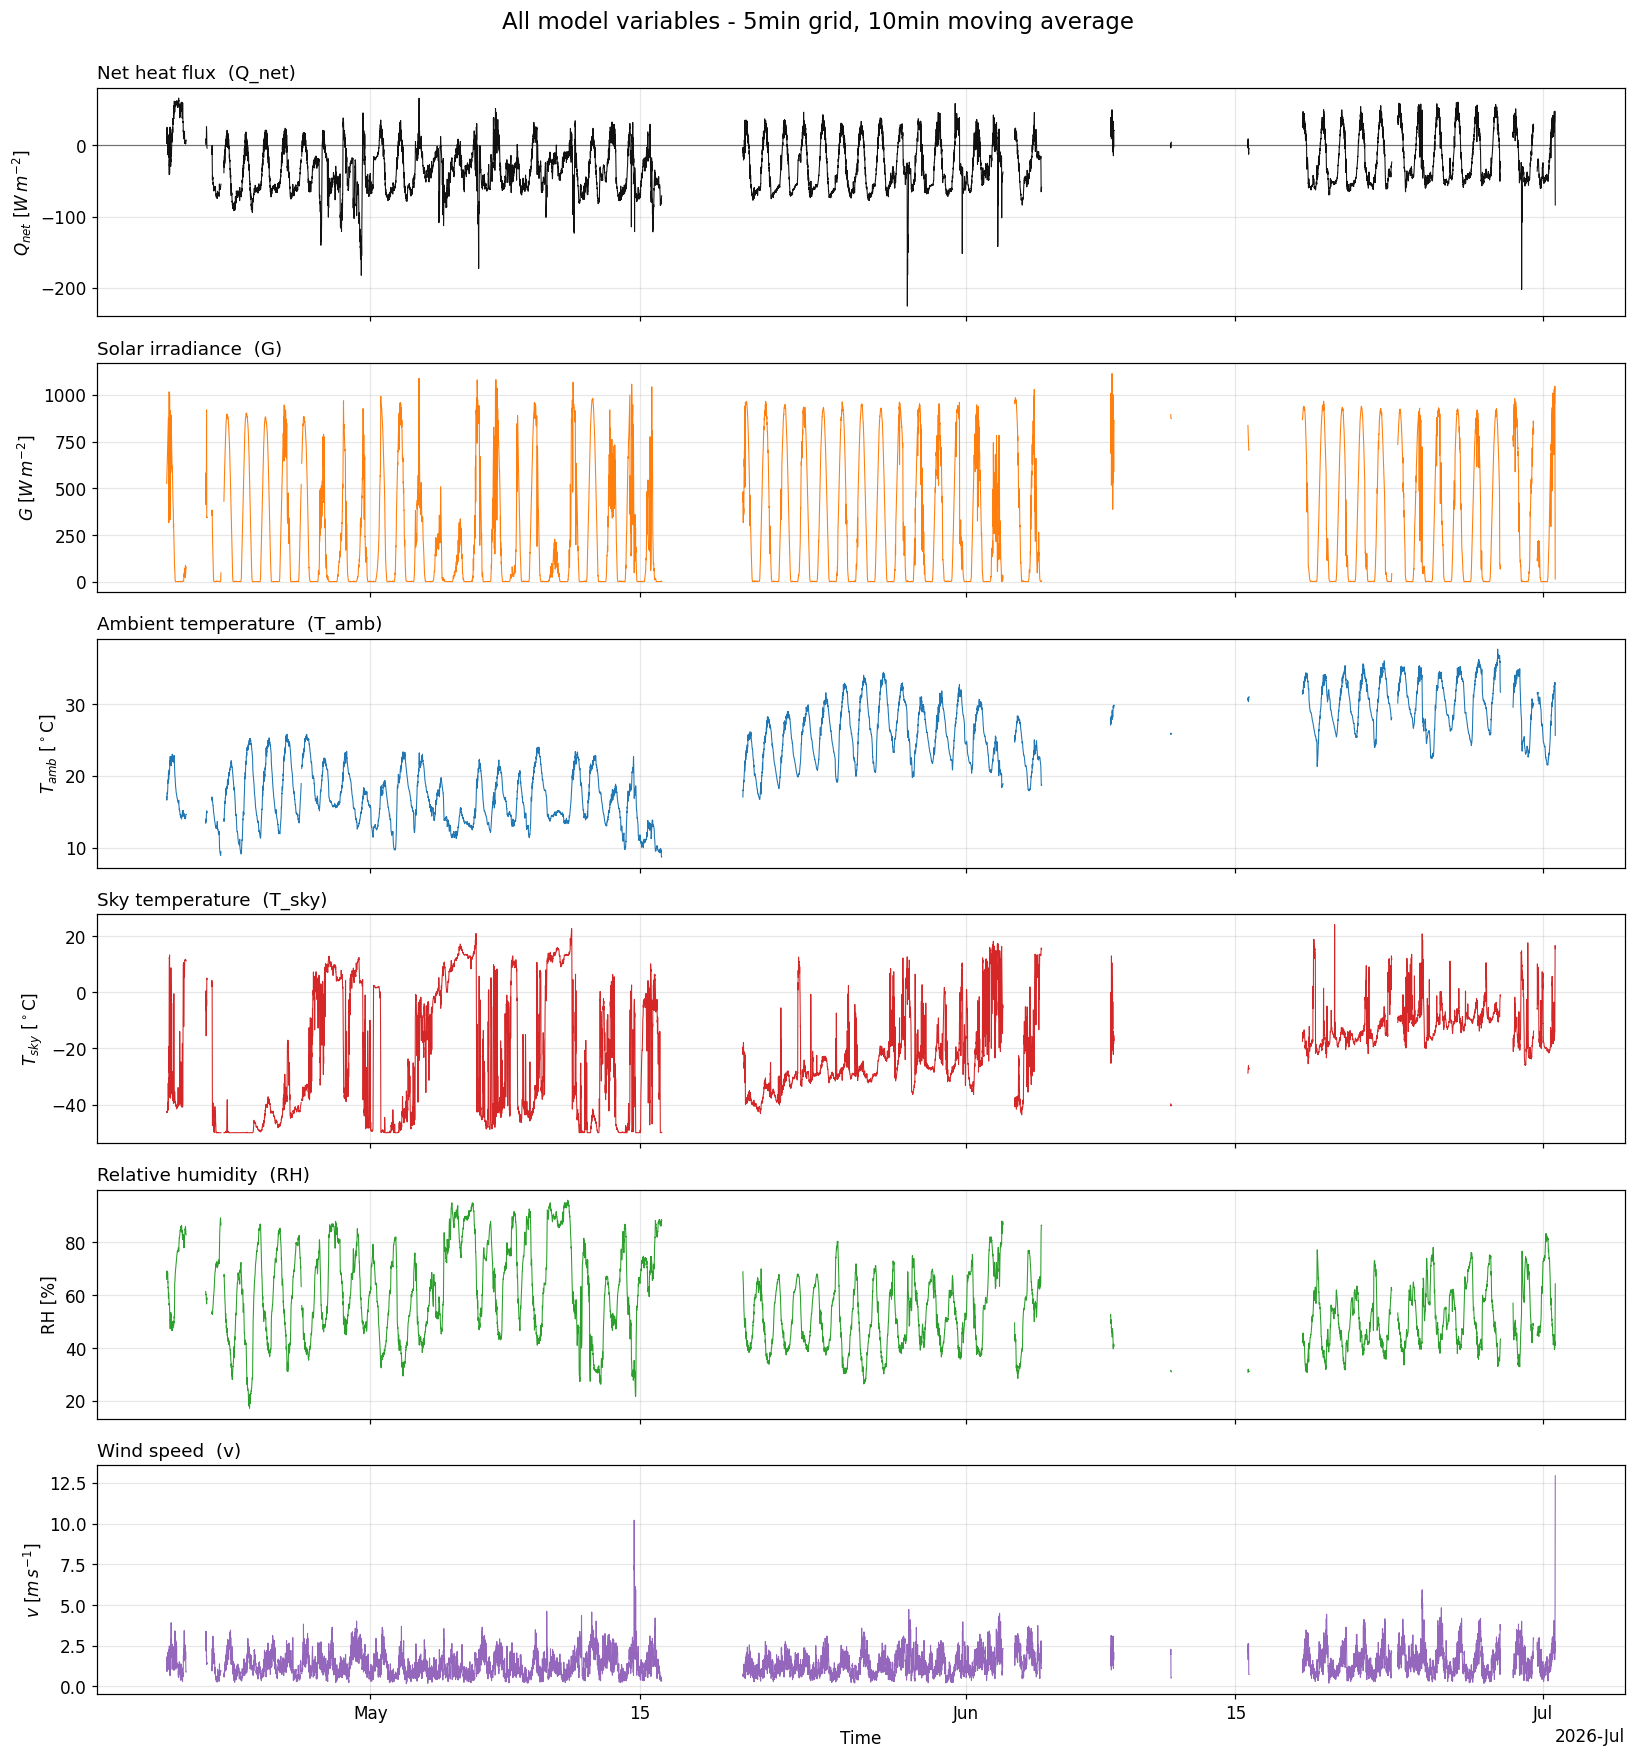

In [13]:
order = ["Q_net", "G", "T_amb", "T_sky", "RH", "v"]

fig, axes = plt.subplots(len(order), 1, figsize=(15, 16), sharex=True)
for ax, col in zip(axes, order):
    title, ylabel, colour = LABELS[col]
    ax.plot(plot_view.index, plot_view[col], color=colour, linewidth=0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title}  ({col})", loc="left", fontsize=12)
    if col == "Q_net":
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
fig.suptitle(f"All model variables - {GRID} grid, {SMOOTH} moving average", y=0.997, fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_all_signals.png")
plt.show()

### The same signals as individual publication-size figures

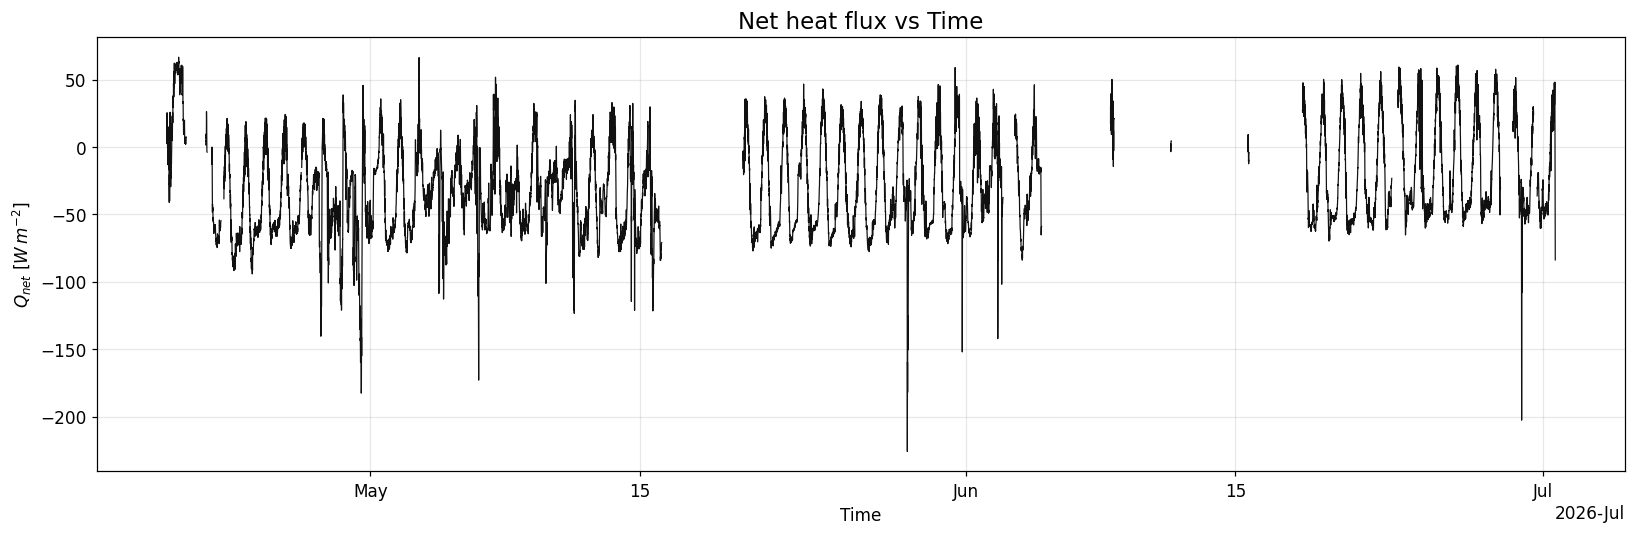

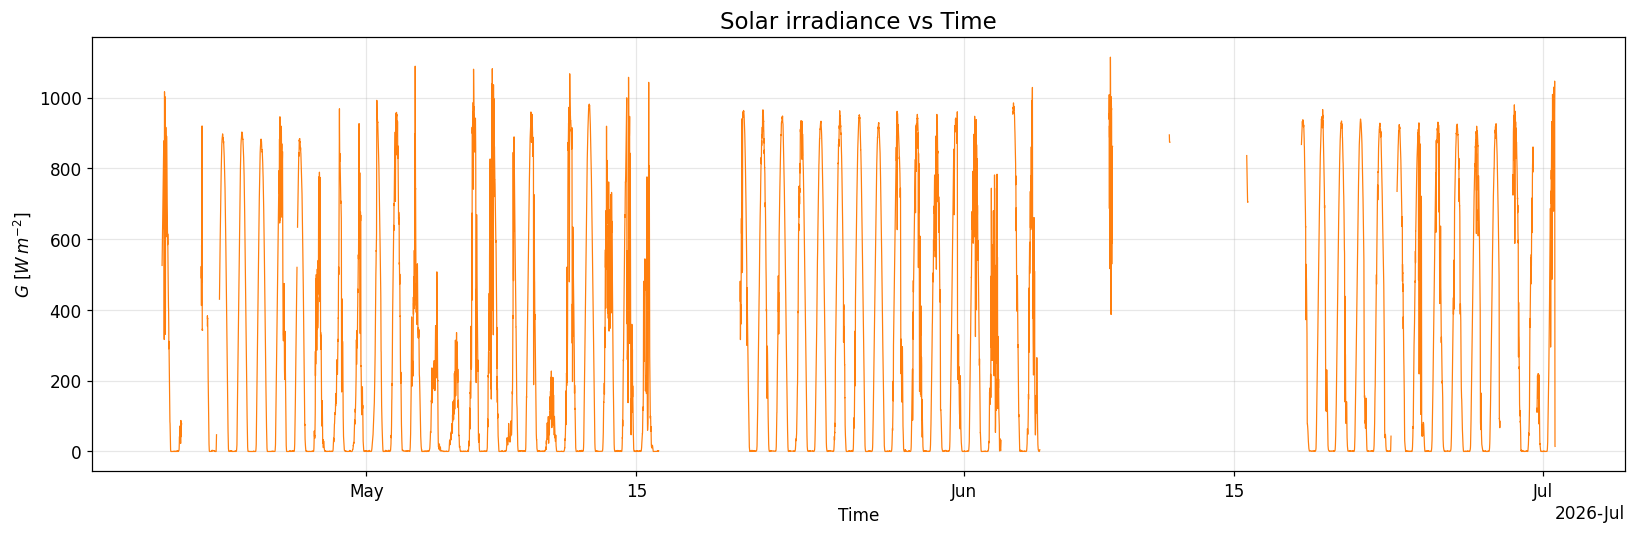

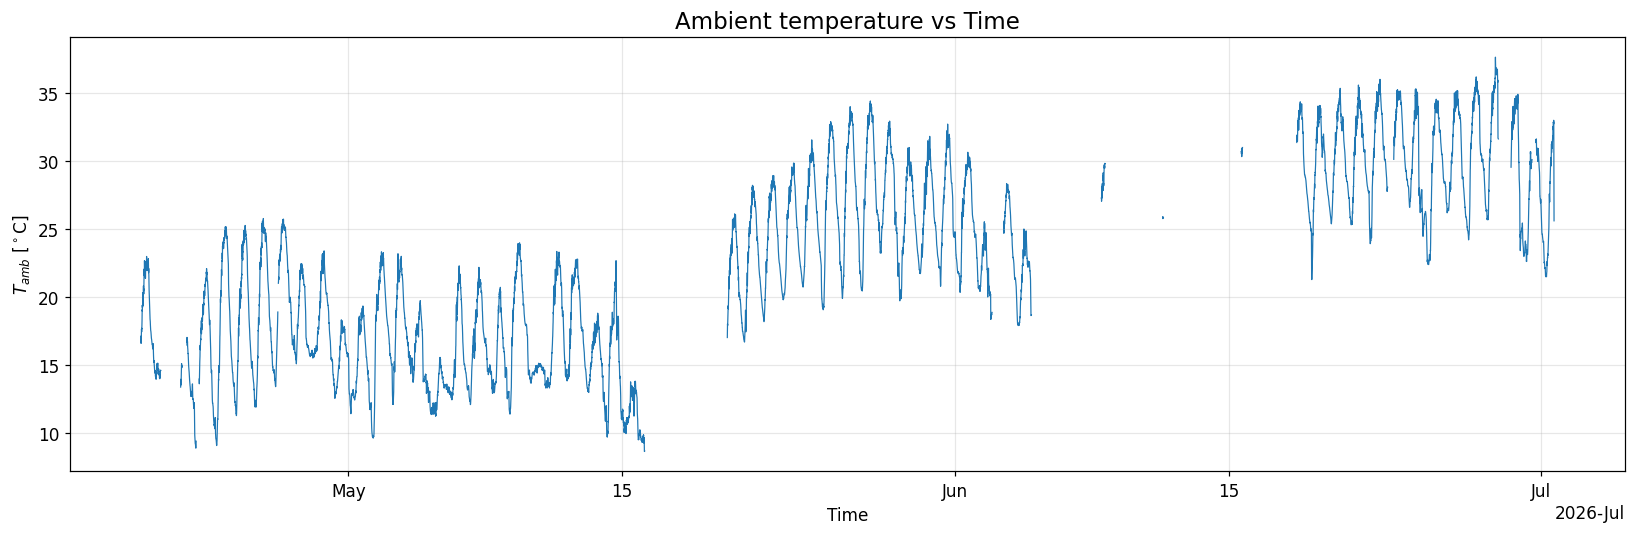

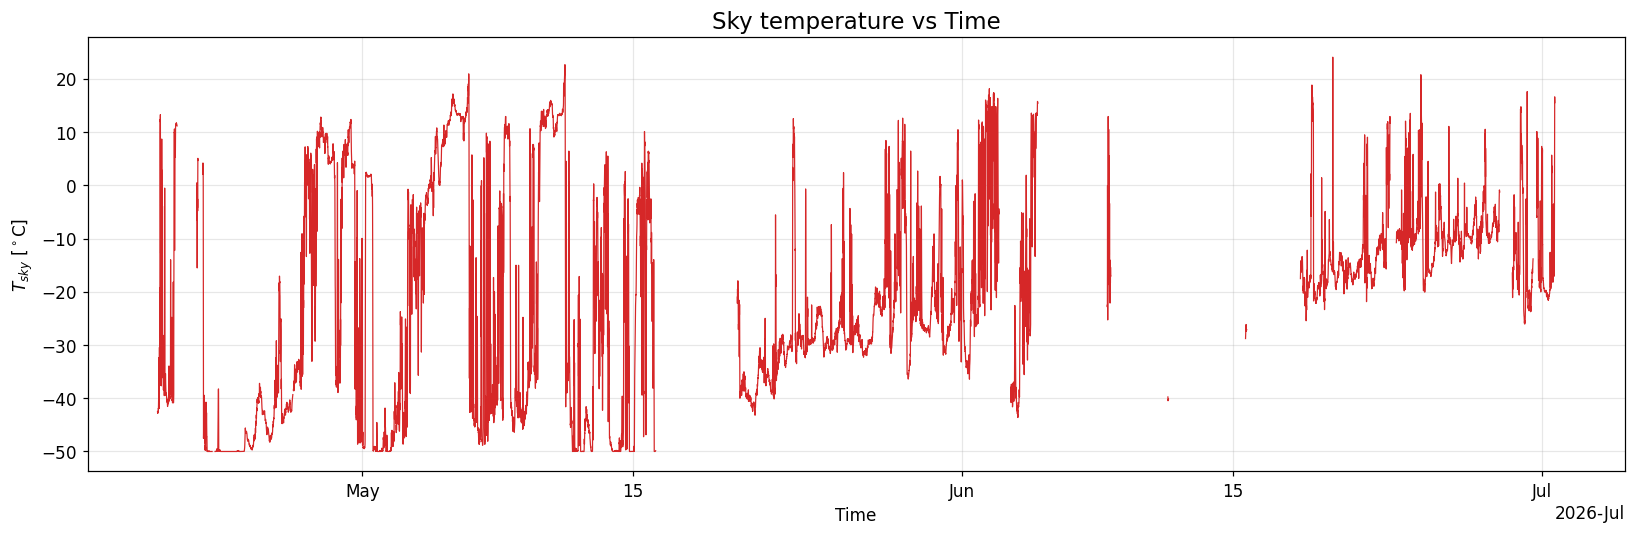

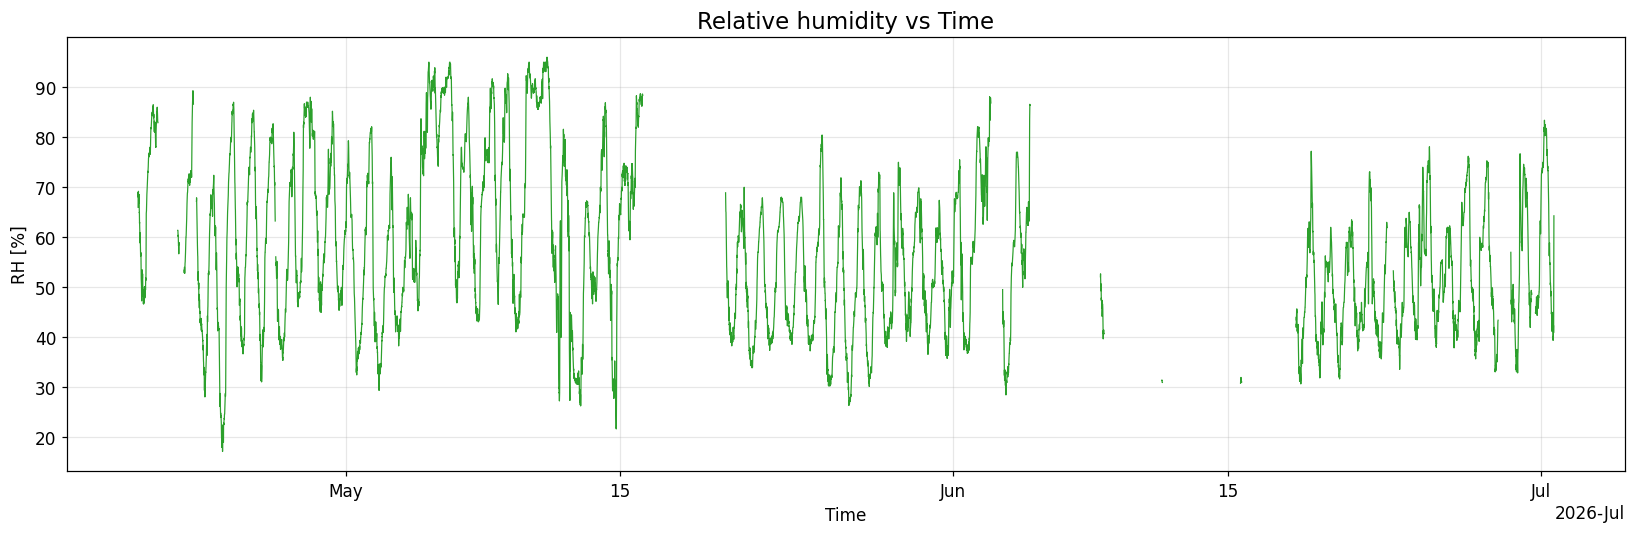

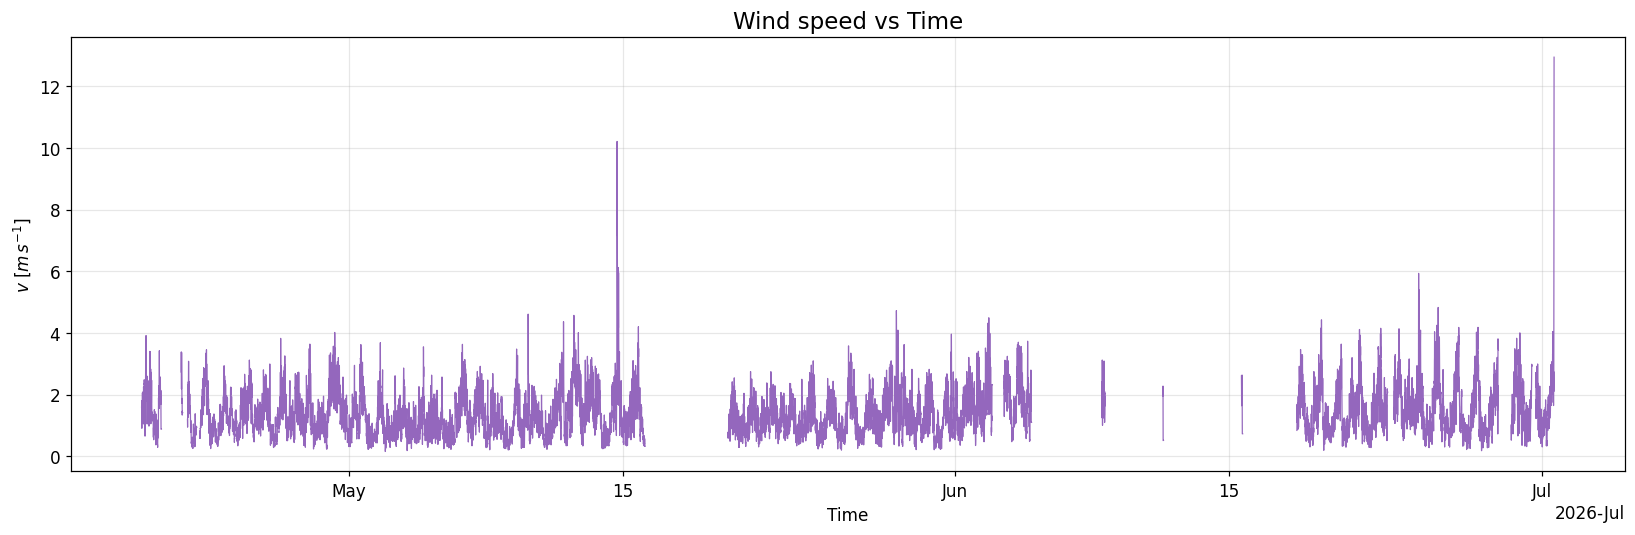

Saved 6 figures (png + pdf) to C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\DIpu_Bhai_thesis\Dipu_Bhai_Thesis\processed\figures_clean


In [14]:
for col in order:
    title, ylabel, colour = LABELS[col]
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(plot_view.index, plot_view[col], color=colour, linewidth=0.8)
    locator = mdates.AutoDateLocator(minticks=5, maxticks=12)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.set_title(f"{title} vs Time", fontsize=15)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{col}_vs_time.{ext}")
    plt.show()

print(f"Saved {len(order)} figures (png + pdf) to {FIG_DIR}")

## 7 - Two diagnostics worth having in the thesis

The supervisor's argument for a neural network (00:27:38) is that the atmospheric variables are
*not* linearly related to the flux — temperature enters as $T^4$, and temperature and humidity
interact. These two plots are the evidence for that claim.

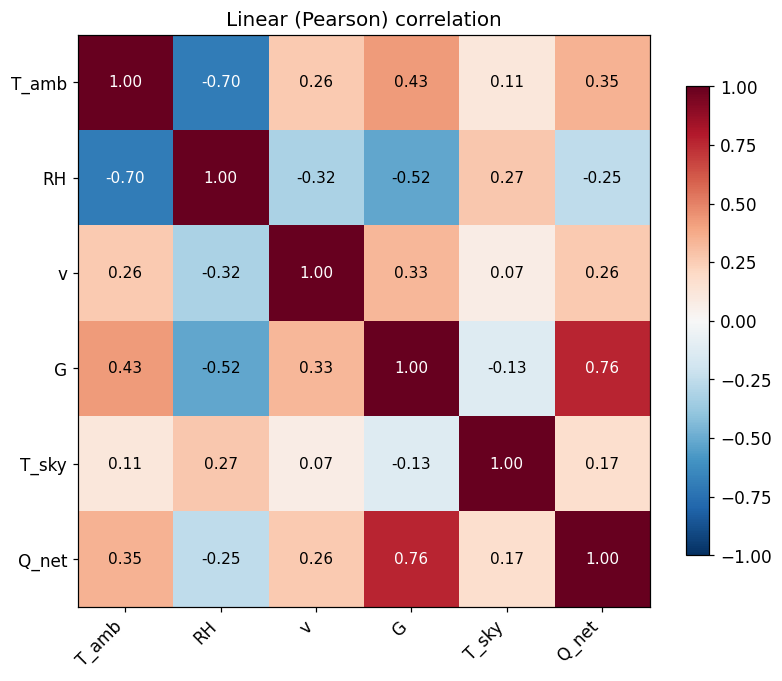

Linear correlation of each input with Q_net:
G        0.758
T_amb    0.348
v        0.263
RH      -0.255
T_sky    0.166

These are weak-to-moderate, so a plain linear regression would do poorly -- which is
exactly the supervisor's reason for reaching for an MLP.


In [15]:
corr = smooth[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(v) > 0.6 else "black")
ax.set_title("Linear (Pearson) correlation")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.82)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_correlation.png")
plt.show()

print("Linear correlation of each input with Q_net:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3).to_string())
print("\nThese are weak-to-moderate, so a plain linear regression would do poorly -- which is")
print("exactly the supervisor's reason for reaching for an MLP.")

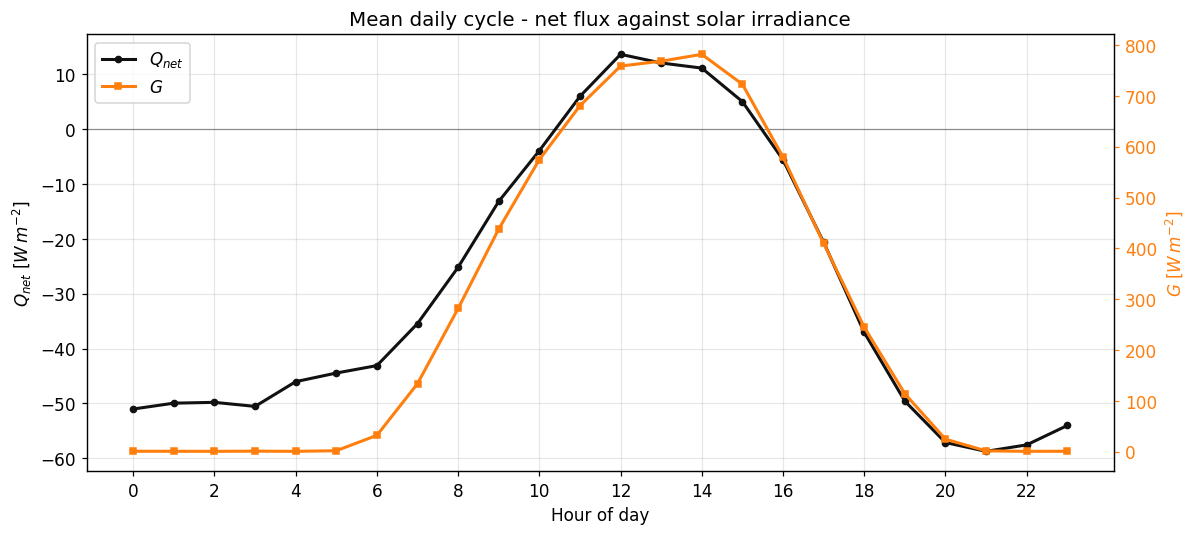

In [16]:
hourly = smooth.groupby(smooth.index.hour).mean()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(hourly.index, hourly[TARGET], color="#111111", marker="o",
               markersize=4, linewidth=2, label=r"$Q_{net}$")
l2, = ax2.plot(hourly.index, hourly["G"], color="#ff7f0e", marker="s",
               markersize=4, linewidth=2, label=r"$G$")

ax1.axhline(0, color="black", linewidth=0.8, alpha=0.4)
ax1.set_xlabel("Hour of day")
ax1.set_ylabel(LABELS[TARGET][1])
ax2.set_ylabel(LABELS["G"][1], color="#ff7f0e")
ax2.tick_params(axis="y", colors="#ff7f0e")
ax2.grid(False)
ax1.set_xticks(range(0, 24, 2))
ax1.set_title("Mean daily cycle - net flux against solar irradiance")
ax1.legend(handles=[l1, l2], loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_daily_cycle.png")
plt.show()

## 8 - Save the preprocessed table

> *"generate your Excel with the merged data ... and then start again by reading that Excel so you
> don't have to generate every time you run your code"* — 00:31:24

This file is the input to the modelling notebook. The preprocessing above never has to run again.

In [17]:
out = smooth[FEATURES + [TARGET]].copy()
out.to_csv(OUT_PATH, index_label="timestamp")

print(f"Saved -> {OUT_PATH}")
print(f"        {len(out):,} rows x {out.shape[1]} columns, "
      f"uniform {GRID} grid, {SMOOTH} smoothed")
print(f"        {out.index.min()}  ->  {out.index.max()}")
print()
display(out.describe().T[["count", "mean", "std", "min", "max"]].round(2))
out.head()

Saved -> C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\DIpu_Bhai_thesis\Dipu_Bhai_Thesis\processed\model_input_5min.csv
        14,859 rows x 6 columns, uniform 5min grid, 10min smoothed
        2026-04-20 09:40:00  ->  2026-07-01 15:25:00



,count,mean,std,min,max
T_amb,14859.0,22.41,6.77,8.65,37.64
RH,14859.0,57.43,16.22,17.20,96.00
v,14859.0,1.40,0.76,0.16,12.94
G,14859.0,280.56,337.64,0.00,1114.30
T_sky,14859.0,-20.66,19.08,-50.00,24.06
Q_net,14859.0,-28.89,35.05,-225.94,66.66


,T_amb,RH,v,G,T_sky,Q_net
timestamp,,,,,,
2026-04-20 09:40:00,17.125,66.0,1.585,525.75,-42.55,12.314356
2026-04-20 09:45:00,17.000,68.0,1.665,539.00,-42.70,9.515419
2026-04-20 09:50:00,16.600,69.0,1.810,557.00,-42.85,10.423587
2026-04-20 09:55:00,16.800,68.0,1.220,572.00,-42.85,2.578113
2026-04-20 10:00:00,17.050,68.5,0.910,584.00,-42.80,17.655541


## Summary

| stage | rows |
|---|---|
| raw merged file | 104,957 |
| `df.dropna()` — the old line | **9,589** (9 days, all April) — 87% of usable rows lost |
| model columns only, then drop | 73,810 (60 days) |
| resampled to a continuous 5-min grid | 20,807 (5-min means plus time-interpolated internal gaps) |
| after the 10-min moving average | **20,806** -> `processed/model_input_5min.csv` |

**Still to raise with the supervisor**

1. **`Q_net` sign convention** — resolved above: negative means heat leaving the sample, so the
   night-time cooling power of 50-70 W/m2 sits inside his 0-100 W/m2 band. Confirm the wording
   with him, but do not flip the values.
2. **`T_sky` saturation** — about 4.7% of raw samples are pinned at the sensor floor of -50 degC.
   These are censored, and they are concentrated on exactly the clear nights that matter most for
   radiative cooling.

**Next step, the model** (his recipe, 00:10:42 -> 00:23:07): `MinMaxScaler` -> random 80/20
`train_test_split` -> `MLPRegressor()` with default hyperparameters -> RMSE and R2 on the
validation set (he wants R2 > 0.8-0.9) -> parity plot of predicted vs measured $Q_{net}$ against
the 1:1 line.

Two notes for when you get there:

- He called the MLP *"a linear neural network"* (00:09:33). That is a slip, and he contradicts it
  himself at 00:27:38. Do not write that in the thesis — an MLP is specifically non-linear.
- *"Bayesian classification"* (00:14:12) is MATLAB vocabulary: `trainbr` is Bayesian-regularisation
  backpropagation, a training algorithm. scikit-learn has no such option (solvers are
  `lbfgs`/`sgd`/`adam`); the equivalent knob is the `alpha` L2 term. And this is **regression**, so
  it is `MLPRegressor`, not `MLPClassifier`.

One caution on his random split: with 5-min resampled and 10-min smoothed data, neighbouring
samples are nearly identical, so a random split leaks information between training and validation
and R2 will come out flatteringly high. Follow his instruction as the primary result, but also
report a chronological split (train April-June, validate July) as a robustness check.